In [1]:
import time
import asyncio
from typing_extensions import TypedDict, List, Dict
from typing import Optional
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage,AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore



In [2]:
# Step 1: Define the state
class State(TypedDict):
    messages: List[Dict[str, str]]

In [3]:
# 2. Set up Gemini LLM
model_id= "gemini-2.0-flash-lite-001"
llm = init_chat_model(model=model_id,model_provider="google_vertexai", project="glassy-keyword-461110-r8")


In [4]:
def bot_node(state: State) -> State:
    user_msg = state["messages"][-1]["content"]
    print("🤖 Calling OpenAI with:", user_msg)
    response = llm([HumanMessage(content=user_msg)]).content
    state["messages"].append({"role": "assistant", "content": response})
    return state

In [5]:
# Step 3: Build and compile the graph
builder = StateGraph(State)
builder.add_node("bot", bot_node)
builder.set_entry_point("bot")

In [6]:
checkpointer = MemorySaver()
store = InMemoryStore()
graph = builder.compile(checkpointer=checkpointer, store=store)



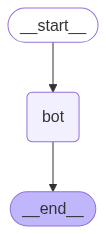

In [7]:
from utils import draw_graph
draw_graph(graph)

In [8]:
# Shared input
initial_state = {
    "messages": [{"role": "user", "content": "What is LangGraph used for?"}]
}

In [9]:
# === RUN WITH .stream() ===
print("\n🔄 Running with `.stream()`:\n")
for step in graph.stream(initial_state,config={"configurable": {"thread_id": "run1"}}):
    if "node" in step:
        print(f"🧩 Step: {step['node']}")
        print(f"📥 State so far: {step['state']}\n")
    elif "final" in step:
        print("✅ Final Output:", step["final"])


🔄 Running with `.stream()`:

🤖 Calling OpenAI with: What is LangGraph used for?


C:\Users\bhargav#\AppData\Local\Temp\ipykernel_16988\659006429.py:4: LangChainDeprecationWarning: The method `BaseChatModel.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  response = llm([HumanMessage(content=user_msg)]).content
